### Download Data From Kaggle

In [234]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("arshid/iris-flower-dataset")

print("Path to dataset files:", path)

Path to dataset files: /Users/edwinchleung/.cache/kagglehub/datasets/arshid/iris-flower-dataset/versions/1


### Exploring The Data

In [235]:
import pandas as pd

df = pd.read_csv(path + "/IRIS.csv")

df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [236]:
df.shape

(150, 5)

In [237]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [238]:
df.isna().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [239]:
df.duplicated().sum() 

np.int64(3)

In [240]:
df[df.duplicated()]

,sepal_length,sepal_width,petal_length,petal_width,species
34,4.9,3.1,1.5,0.1,Iris-setosa
37,4.9,3.1,1.5,0.1,Iris-setosa
142,5.8,2.7,5.1,1.9,Iris-virginica


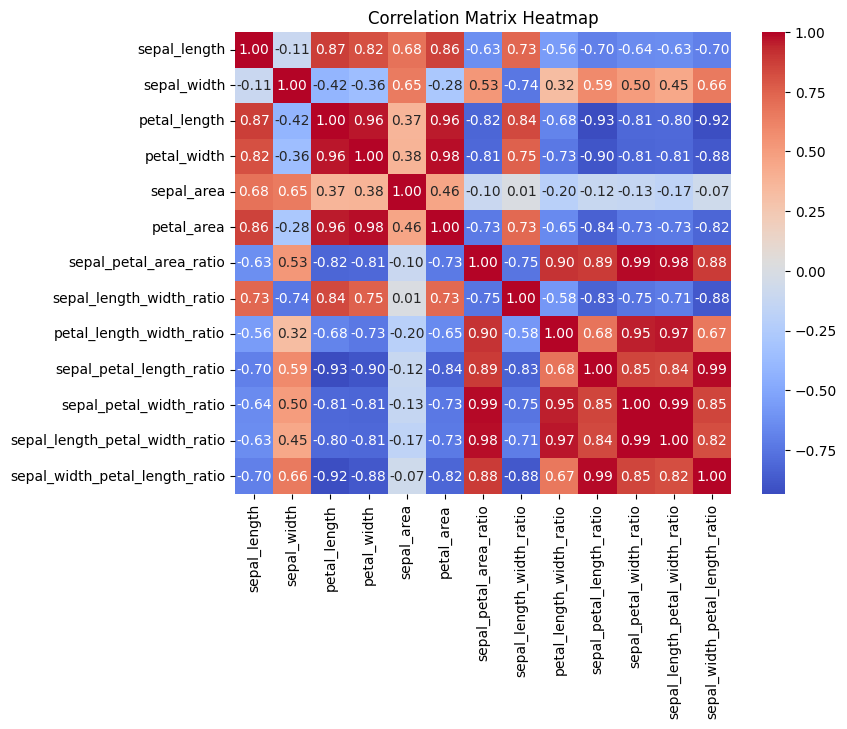

In [241]:
import matplotlib.pyplot as plt
import seaborn as sns

# Feature Engineering

# Area Features
df['sepal_area'] = df['sepal_length'] * df['sepal_width']
df['petal_area'] = df['petal_length'] * df['petal_width']

# Ratio Features
df['sepal_petal_area_ratio'] = df['sepal_area'] / df['petal_area']
df['sepal_length_width_ratio'] = df['sepal_length'] / df['sepal_width']
df['petal_length_width_ratio'] = df['petal_length'] / df['petal_width']
df['sepal_petal_length_ratio'] = df['sepal_length'] / df['petal_length']
df['sepal_petal_width_ratio'] = df['sepal_width'] / df['petal_width']
df['sepal_length_petal_width_ratio'] = df['sepal_length'] / df['petal_width']
df['sepal_width_petal_length_ratio'] = df['sepal_width'] / df['petal_length']

features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'sepal_area', 'petal_area', 'sepal_petal_area_ratio', 'sepal_length_width_ratio', 'petal_length_width_ratio', 'sepal_petal_length_ratio', 'sepal_petal_width_ratio', 'sepal_length_petal_width_ratio', 'sepal_width_petal_length_ratio']
species_list = df['species'].unique()

plt.figure(figsize=(8, 6))
sns.heatmap(df[features].corr(), annot=True, cmap='coolwarm', fmt=".2f")

plt.title('Correlation Matrix Heatmap')
plt.show()

In [242]:
df.groupby("species").agg(["count", "mean", "std", "min", "max"]).T

species                               Iris-setosa  Iris-versicolor  \
sepal_length                   count    50.000000        50.000000   
                               mean      5.006000         5.936000   
                               std       0.352490         0.516171   
                               min       4.300000         4.900000   
                               max       5.800000         7.000000   
...                                           ...              ...   
sepal_width_petal_length_ratio count    50.000000        50.000000   
                               mean      2.363368         0.653833   
                               std       0.372974         0.069860   
                               min       1.769231         0.488889   
                               max       3.600000         0.833333   

species                               Iris-virginica  
sepal_length                   count       50.000000  
                               mean         6.588000  
                               std          0.635880  
                               min          4.900000  
                               max          7.900000  
...                                              ...  
sepal_width_petal_length_ratio count       50.000000  
                               mean         0.538352  
                               std          0.057697  
                               min          0.376812  
                               max          0.629630  

[65 rows x 3 columns]

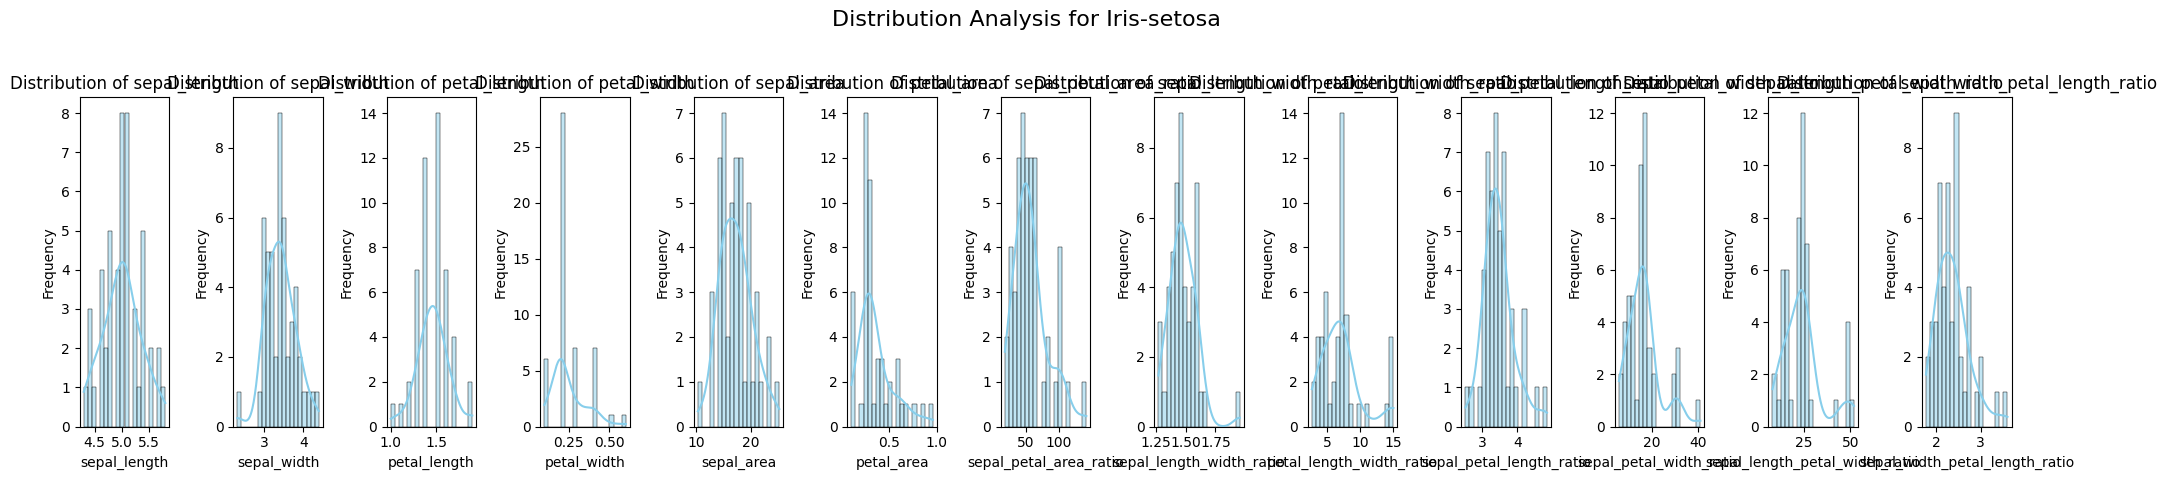

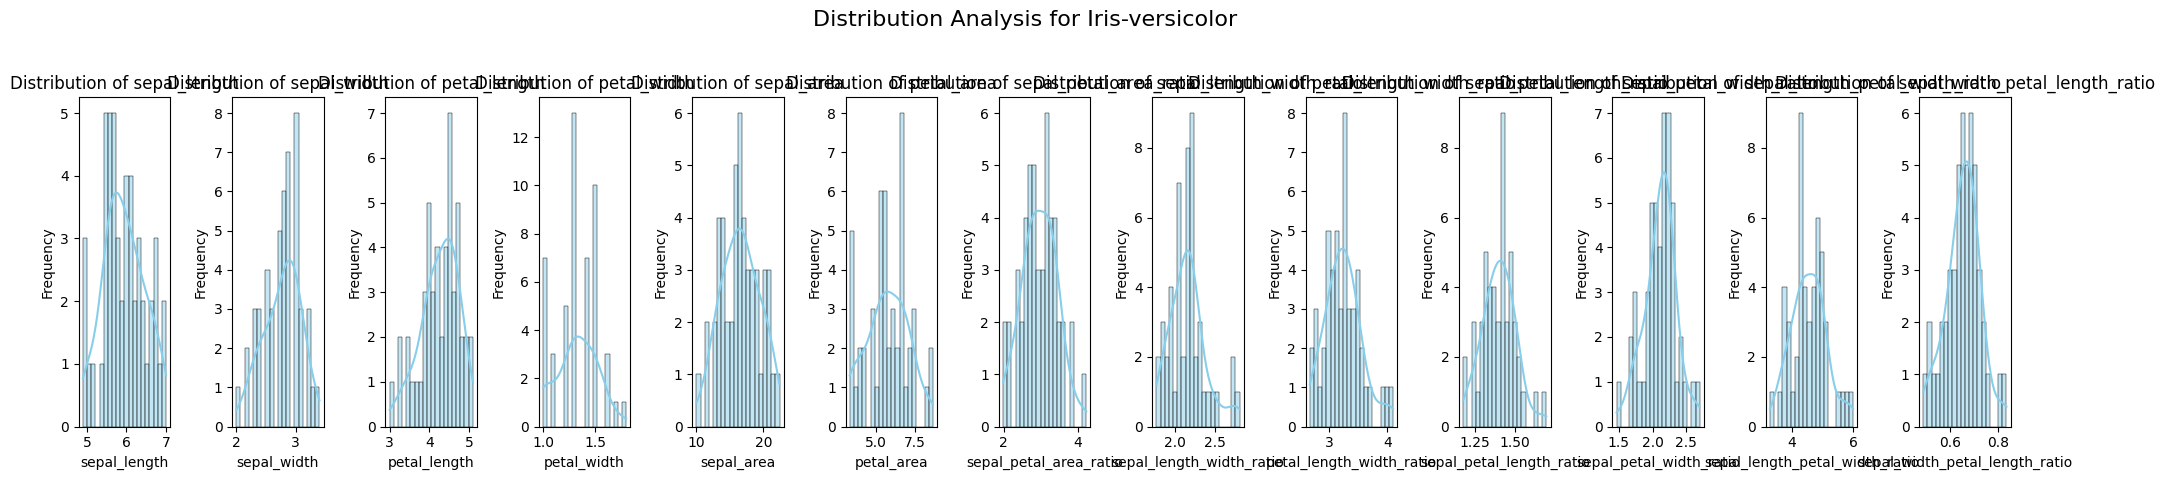

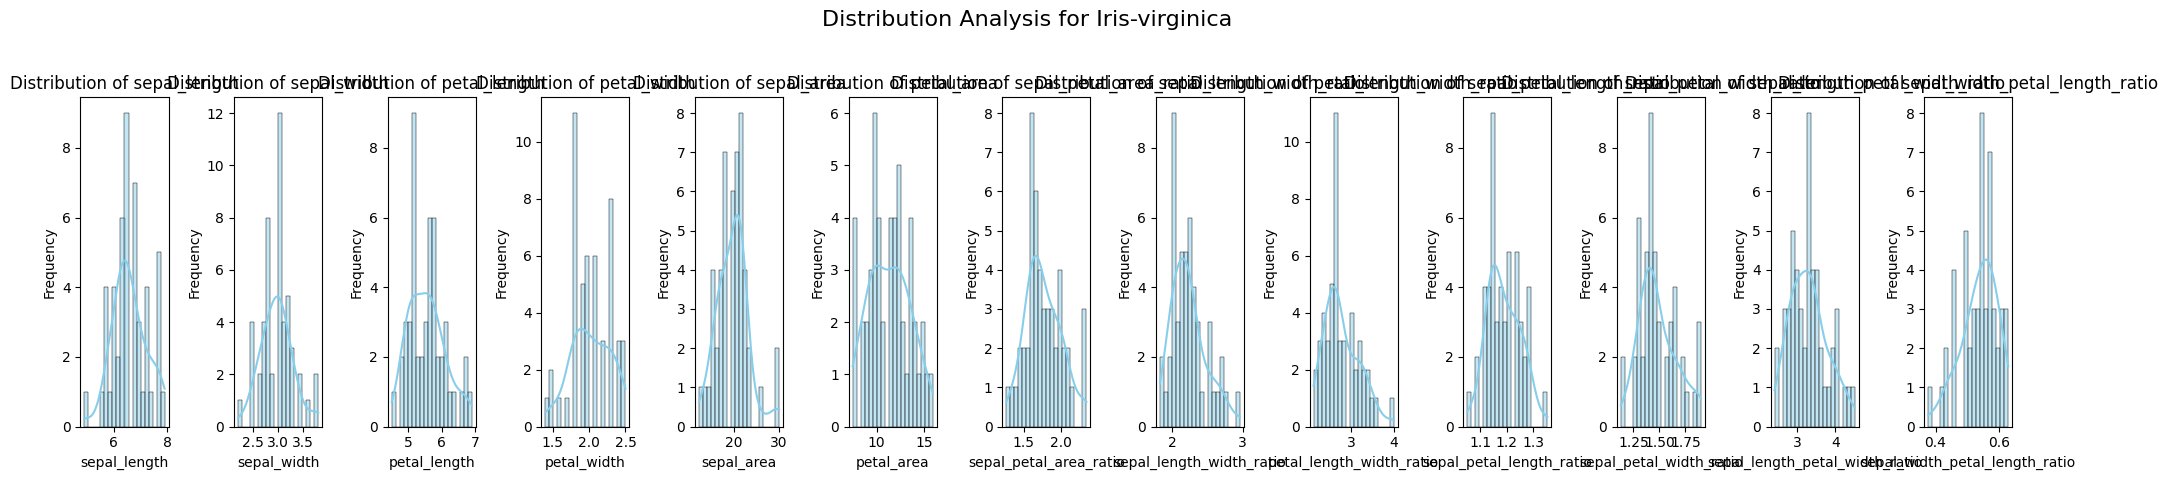

In [243]:
for spec in species_list:
    subset = df[df['species'] == spec]
    
    fig, ax = plt.subplots(1, len(features), figsize=(20, 5))
    fig.suptitle(f'Distribution Analysis for {spec}', fontsize=16)
    
    for i, col in enumerate(features):
        sns.histplot(subset[col], kde=True, ax=ax[i], color='skyblue', bins=20)
        
        ax[i].set_title(f'Distribution of {col}')
        ax[i].set_xlabel(col)
        ax[i].set_ylabel('Frequency')
    
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

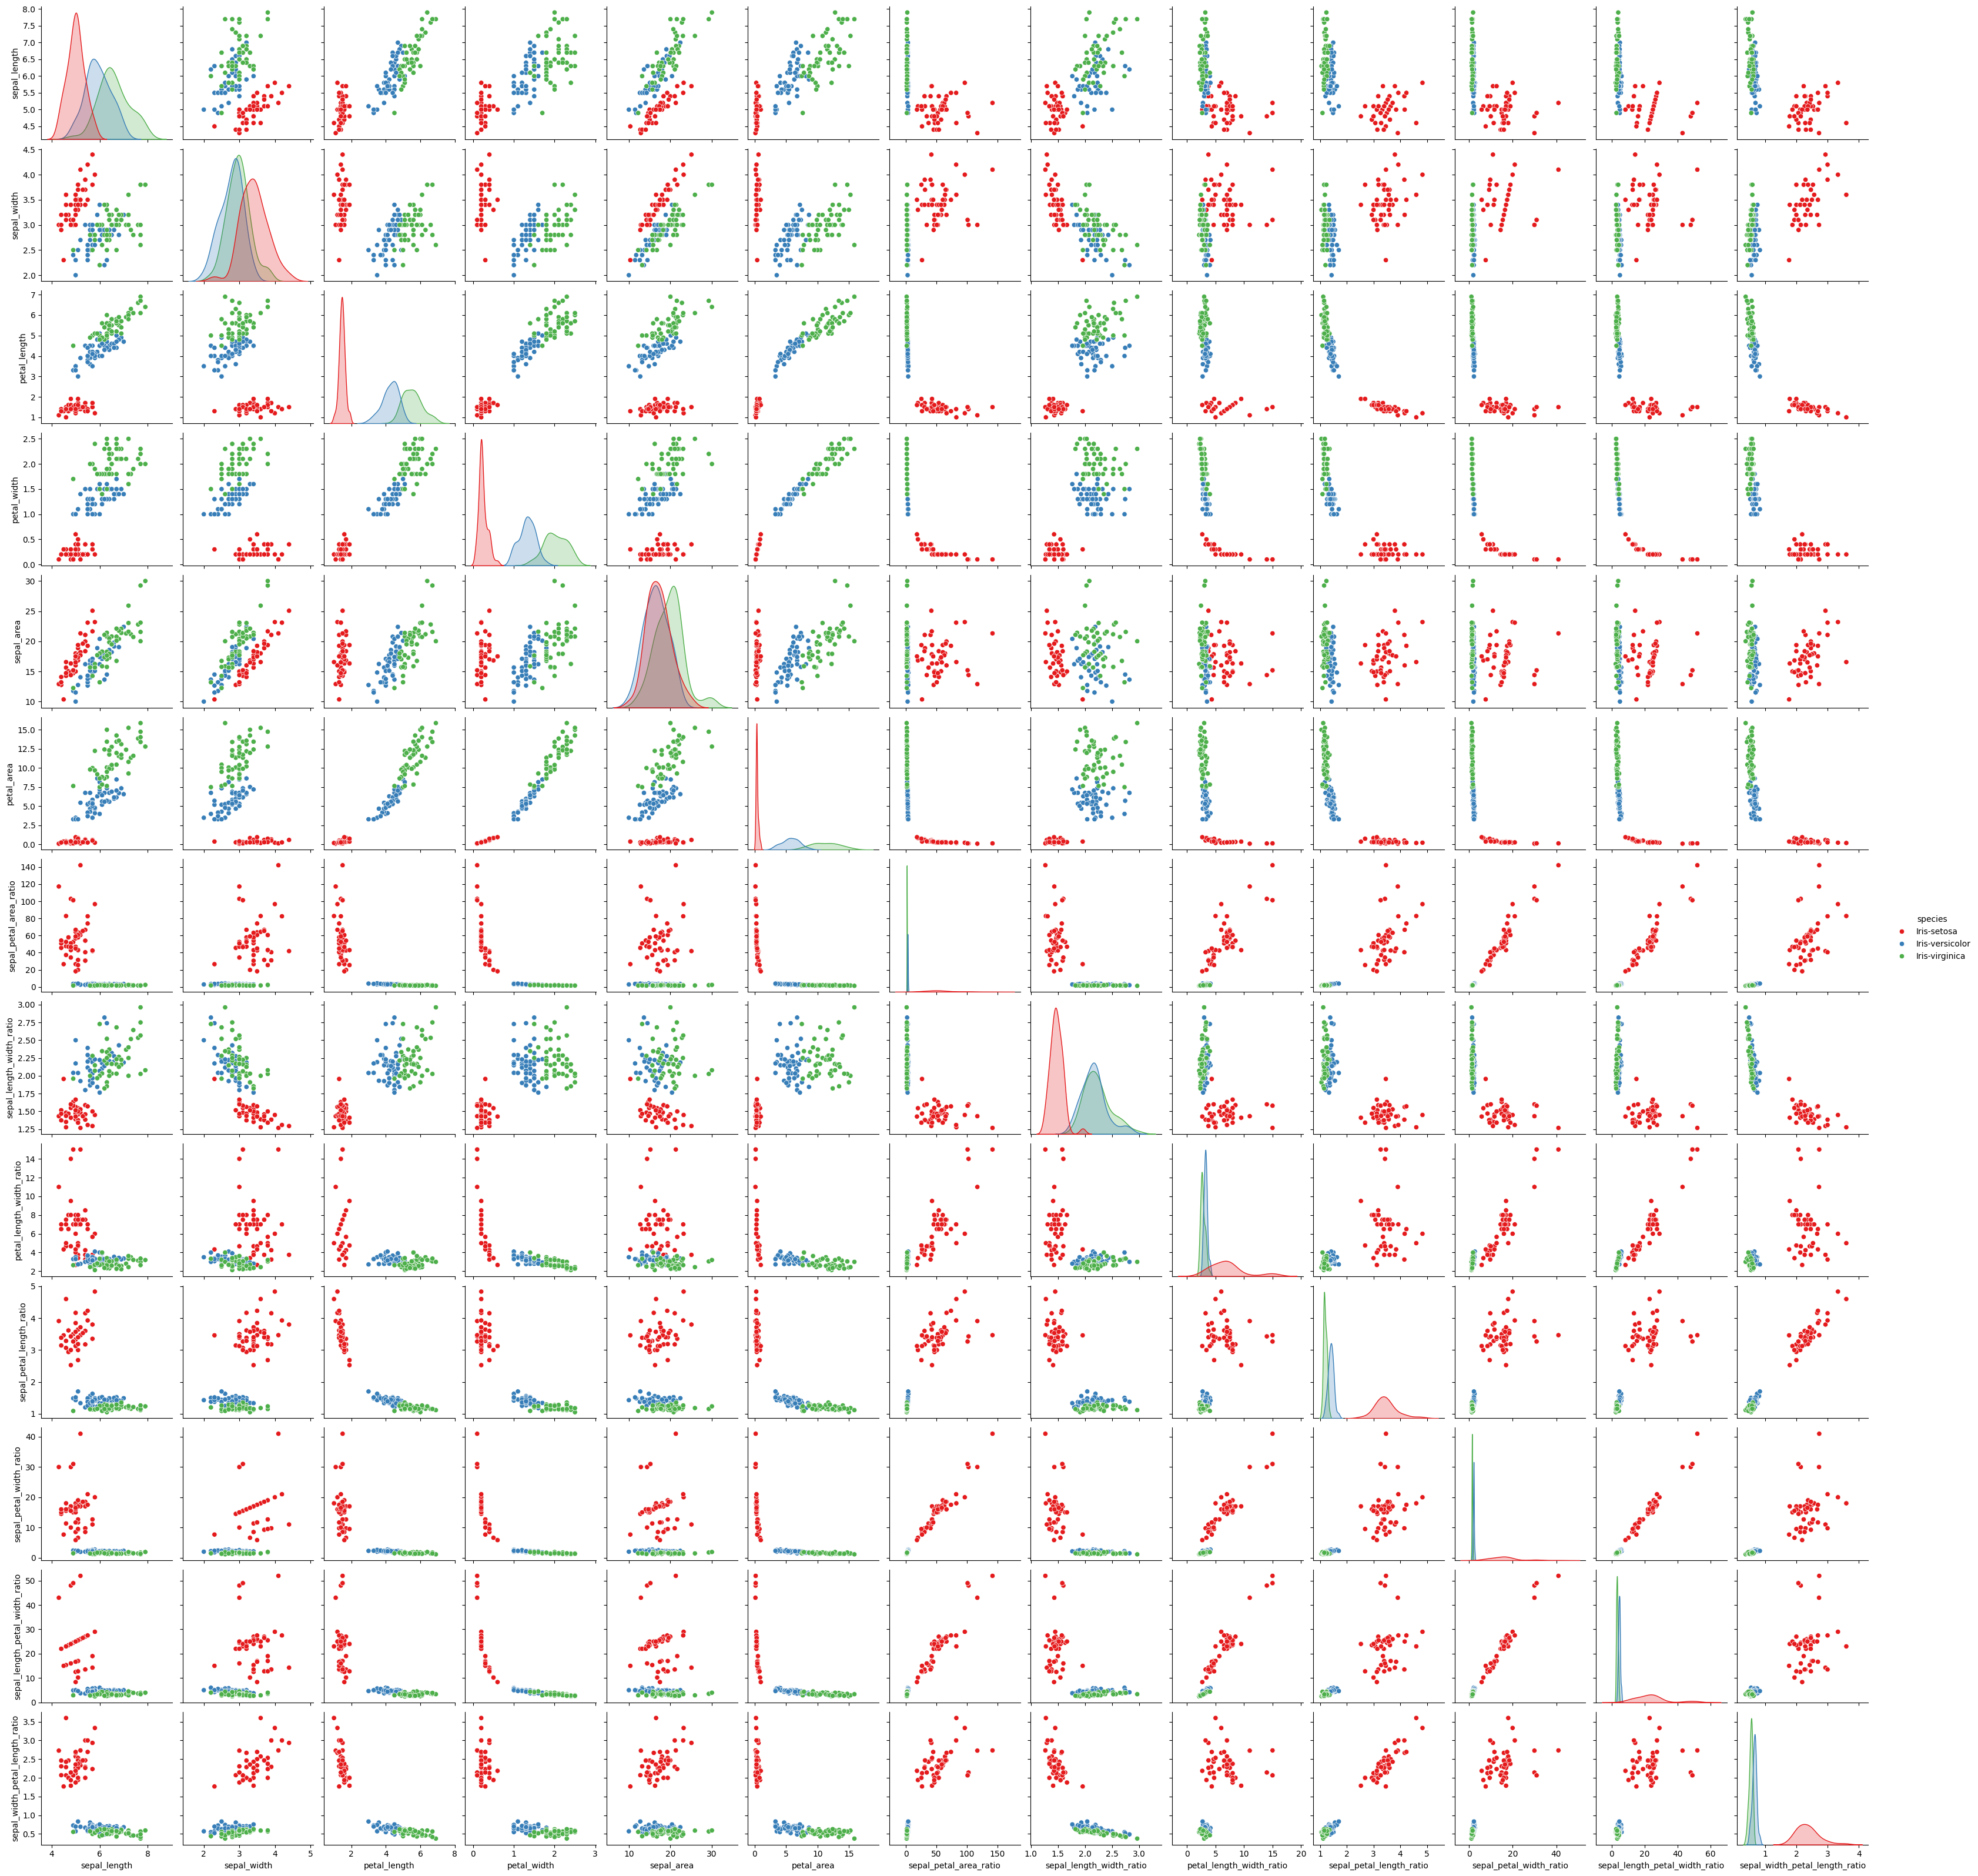

In [244]:
sns.pairplot(df, hue='species', palette='Set1')
plt.show()

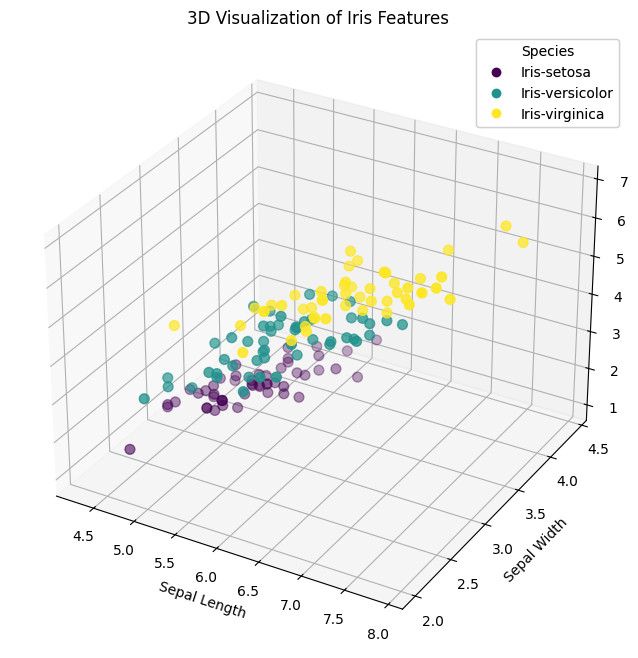

In [245]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Data points
x = df['sepal_length']
y = df['sepal_width']
z = df['petal_length']

# Create the scatter
scatter = ax.scatter(x, y, z, c=df['species'].astype('category').cat.codes, cmap='viridis', s=50)

legend1 = ax.legend(handles=scatter.legend_elements()[0], 
                    labels=list(df['species'].astype('category').cat.categories),
                    title="Species")
ax.add_artist(legend1)

# Labels
ax.set_xlabel('Sepal Length')
ax.set_ylabel('Sepal Width')
ax.set_zlabel('Petal Length')
ax.set_title('3D Visualization of Iris Features')

plt.show()

We can see that setosa can be easily classified from other 2 species, the distribution of the features is quite different from the other 2

While the other 2 are overlapping with some features

### Modelling

#### Logistic regression

In [246]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve, accuracy_score

# Encode target variable
le = LabelEncoder()
df['species_encoded'] = le.fit_transform(df['species'])

df[['species', 'species_encoded']]

,species,species_encoded
0,Iris-setosa,0
1,Iris-setosa,0
2,Iris-setosa,0
3,Iris-setosa,0
4,Iris-setosa,0
...,...,...
145,Iris-virginica,2
146,Iris-virginica,2
147,Iris-virginica,2
148,Iris-virginica,2


In [247]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(df[features], df['species_encoded'], test_size=0.3, random_state=42, shuffle=True, stratify=df['species_encoded'])

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [248]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(random_state=42)

logistic_model.fit(X_train_scaled, y_train)

y_train_pred_logistic = logistic_model.predict(X_train_scaled)
y_test_pred_logistic = logistic_model.predict(X_test_scaled)

Train Set Classification Report for Logistic Regression Model:
Accuracy: 0.9809523809523809
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        35
Iris-versicolor       0.97      0.97      0.97        35
 Iris-virginica       0.97      0.97      0.97        35

       accuracy                           0.98       105
      macro avg       0.98      0.98      0.98       105
   weighted avg       0.98      0.98      0.98       105



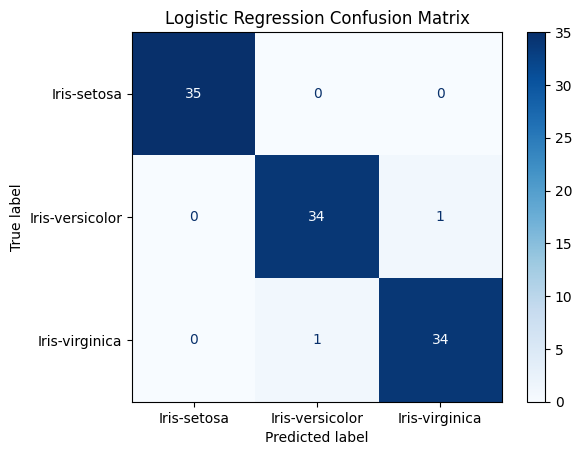

In [249]:
print("Train Set Classification Report for Logistic Regression Model:")
print("Accuracy:", accuracy_score(y_train, y_train_pred_logistic))
print(classification_report(y_train, y_train_pred_logistic, target_names=le.classes_))
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred_logistic, display_labels=le.classes_, cmap='Blues')
plt.title("Logistic Regression Confusion Matrix")
plt.show()

Test Set Classification Report for Logistic Regression Model:
Accuracy: 0.9111111111111111
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        15
Iris-versicolor       0.82      0.93      0.88        15
 Iris-virginica       0.92      0.80      0.86        15

       accuracy                           0.91        45
      macro avg       0.92      0.91      0.91        45
   weighted avg       0.92      0.91      0.91        45



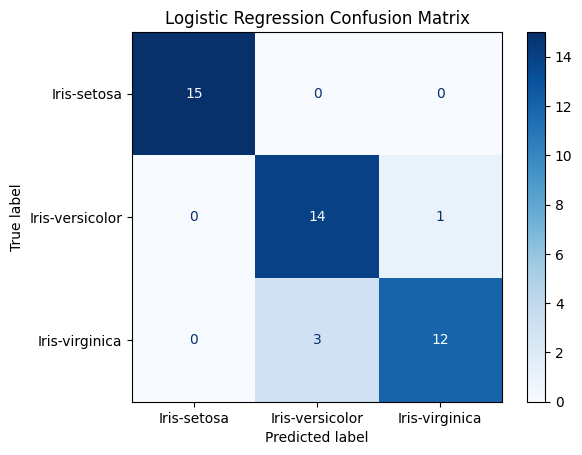

In [250]:
print("Test Set Classification Report for Logistic Regression Model:")
print("Accuracy:", accuracy_score(y_test, y_test_pred_logistic))
print(classification_report(y_test, y_test_pred_logistic, target_names=le.classes_))
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred_logistic, display_labels=le.classes_, cmap='Blues')
plt.title("Logistic Regression Confusion Matrix")
plt.show()

Setosa: 100% accuracy

Verisicolor & virginica: mostly correct

#### Random Forest

In [251]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(random_state=42, n_estimators=100)
random_forest_model.fit(X_train_scaled, y_train)

y_train_pred_rf = random_forest_model.predict(X_train_scaled)
y_test_pred_rf = random_forest_model.predict(X_test_scaled)

Train Set Classification Report for Random Forest Model:
Accuracy: 1.0
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        35
Iris-versicolor       1.00      1.00      1.00        35
 Iris-virginica       1.00      1.00      1.00        35

       accuracy                           1.00       105
      macro avg       1.00      1.00      1.00       105
   weighted avg       1.00      1.00      1.00       105



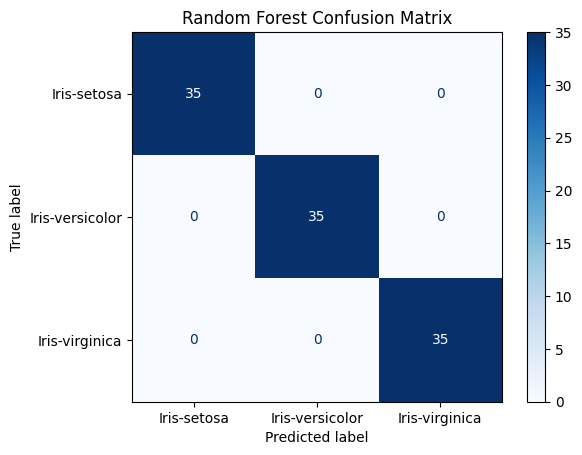

In [252]:
print("Train Set Classification Report for Random Forest Model:")
print("Accuracy:", accuracy_score(y_train, y_train_pred_rf))
print(classification_report(y_train, y_train_pred_rf, target_names=le.classes_))
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred_rf, display_labels=le.classes_, cmap='Blues')
plt.title("Random Forest Confusion Matrix")
plt.show()

Test Set Classification Report for Random Forest Model:
Accuracy: 0.9555555555555556
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        15
Iris-versicolor       0.88      1.00      0.94        15
 Iris-virginica       1.00      0.87      0.93        15

       accuracy                           0.96        45
      macro avg       0.96      0.96      0.96        45
   weighted avg       0.96      0.96      0.96        45



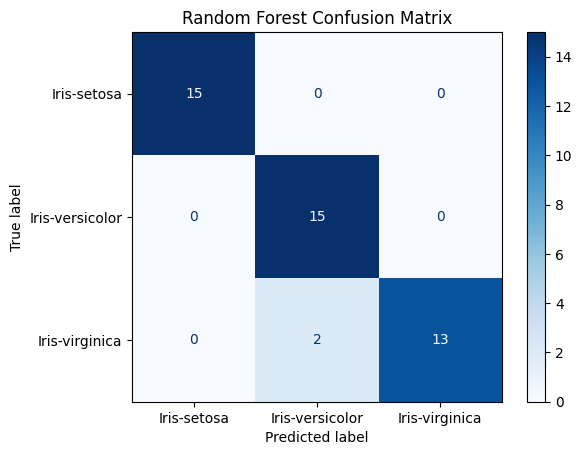

In [253]:
print("Test Set Classification Report for Random Forest Model:")
print("Accuracy:", accuracy_score(y_test, y_test_pred_rf))
print(classification_report(y_test, y_test_pred_rf, target_names=le.classes_))
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred_rf, display_labels=le.classes_, cmap='Blues')
plt.title("Random Forest Confusion Matrix")
plt.show()

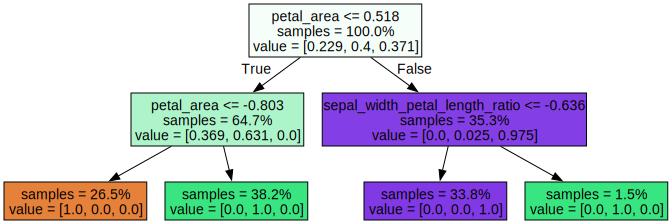

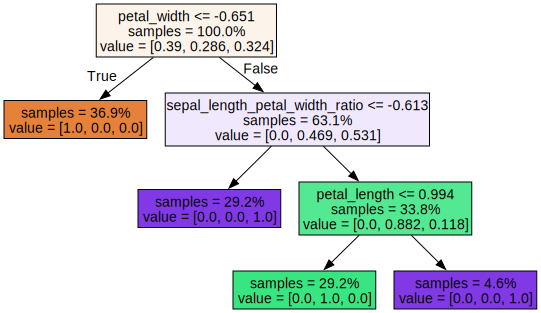

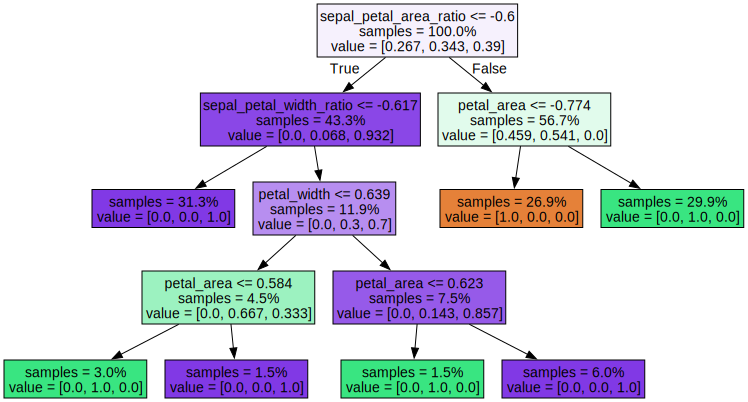

In [254]:
from sklearn.tree import export_graphviz
from IPython.display import Image
import graphviz


for i in range(3):
    tree = random_forest_model.estimators_[i]
    dot_data = export_graphviz(tree,
                               feature_names=X_train.columns,  
                               filled=True,  
                               max_depth=5, 
                               impurity=False, 
                               proportion=True)
    graph = graphviz.Source(dot_data)
    display(graph)

In [255]:
from scipy.stats import randint

param_dist = {
  'n_estimators': randint(100, 500),
  'max_depth': randint(3, 15),
  'min_samples_split': randint(2, 10),
  'min_samples_leaf': randint(1, 5)
}


# Create a random forest classifier
random_forest_model = RandomForestClassifier(random_state=42, n_jobs=-1)

# Use random search to find the best hyperparameters
rand_search = RandomizedSearchCV(
  random_forest_model, param_distributions=param_dist,
  n_iter=10, cv=5, scoring='accuracy',
  n_jobs=-1, random_state=42
)

rand_search.fit(X_train_scaled, y_train)

random_forest_model: RandomForestClassifier = rand_search.best_estimator_

# Print the best hyperparameters
print('Best hyperparameters:',  rand_search.best_params_)

Best hyperparameters: {'max_depth': 9, 'min_samples_leaf': 4, 'min_samples_split': 6, 'n_estimators': 370}


In [256]:
random_forest_model.fit(X_train_scaled, y_train)

y_train_pred_rf = random_forest_model.predict(X_train_scaled)
y_test_pred_rf = random_forest_model.predict(X_test_scaled)

Train Set Classification Report for Tuned Random Forest Model:
Accuracy: 0.9809523809523809
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        35
Iris-versicolor       1.00      0.94      0.97        35
 Iris-virginica       0.95      1.00      0.97        35

       accuracy                           0.98       105
      macro avg       0.98      0.98      0.98       105
   weighted avg       0.98      0.98      0.98       105



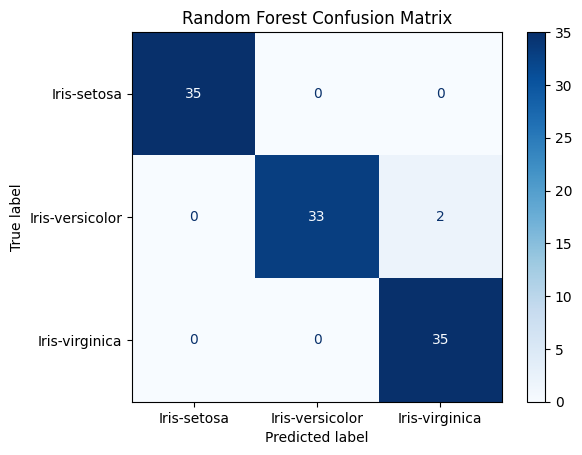

In [257]:
print("Train Set Classification Report for Tuned Random Forest Model:")
print("Accuracy:", accuracy_score(y_train, y_train_pred_rf))
print(classification_report(y_train, y_train_pred_rf, target_names=le.classes_))
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred_rf, display_labels=le.classes_, cmap='Blues')
plt.title("Random Forest Confusion Matrix")
plt.show()

Test Set Classification Report for Tuned Random Forest Model:
Accuracy: 0.9333333333333333
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        15
Iris-versicolor       0.88      0.93      0.90        15
 Iris-virginica       0.93      0.87      0.90        15

       accuracy                           0.93        45
      macro avg       0.93      0.93      0.93        45
   weighted avg       0.93      0.93      0.93        45



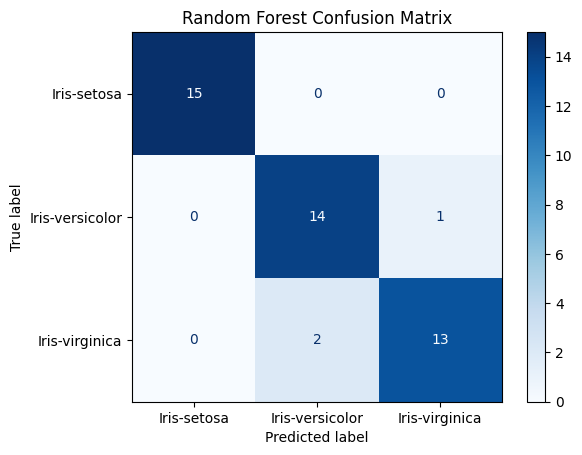

In [258]:
print("Test Set Classification Report for Tuned Random Forest Model:")
print("Accuracy:", accuracy_score(y_test, y_test_pred_rf))
print(classification_report(y_test, y_test_pred_rf, target_names=le.classes_))
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred_rf, display_labels=le.classes_, cmap='Blues')
plt.title("Random Forest Confusion Matrix")
plt.show()

#### XGBoost Classifier

In [259]:
import xgboost as xgb

xgb_model = xgb.XGBClassifier(random_state=42)
xgb_model.fit(X_train_scaled, y_train)

y_train_pred_xgb = xgb_model.predict(X_train_scaled)
y_test_pred_xgb = xgb_model.predict(X_test_scaled)

Train Set Classification Report for XGBoost Model:
Accuracy: 1.0
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        35
Iris-versicolor       1.00      1.00      1.00        35
 Iris-virginica       1.00      1.00      1.00        35

       accuracy                           1.00       105
      macro avg       1.00      1.00      1.00       105
   weighted avg       1.00      1.00      1.00       105



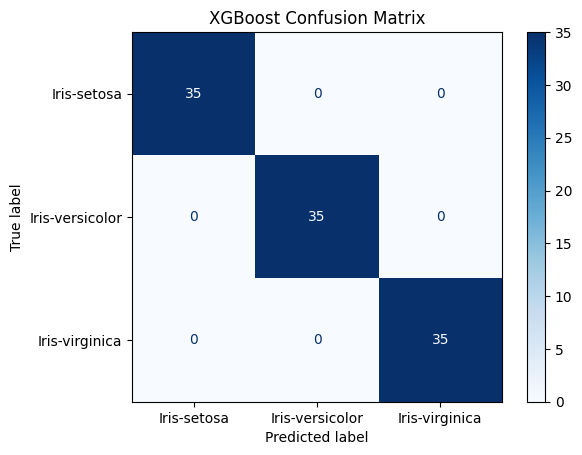

In [260]:
print("Train Set Classification Report for XGBoost Model:")
print("Accuracy:", accuracy_score(y_train, y_train_pred_xgb))
print(classification_report(y_train, y_train_pred_xgb, target_names=le.classes_))
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred_xgb, display_labels=le.classes_, cmap='Blues')
plt.title("XGBoost Confusion Matrix")
plt.show()

Test Set Classification Report for XGBoost Model:
Accuracy: 0.9555555555555556
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        15
Iris-versicolor       0.88      1.00      0.94        15
 Iris-virginica       1.00      0.87      0.93        15

       accuracy                           0.96        45
      macro avg       0.96      0.96      0.96        45
   weighted avg       0.96      0.96      0.96        45



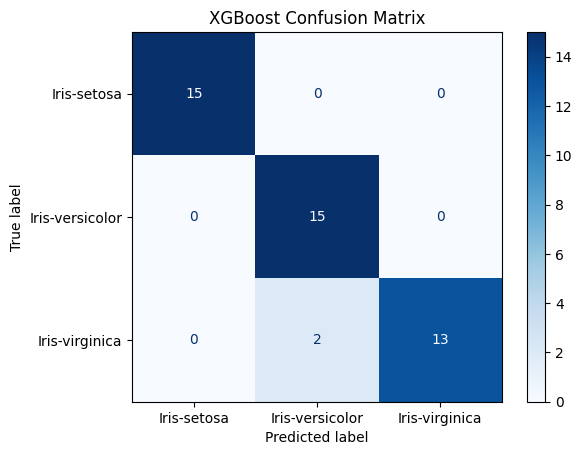

In [261]:
print("Test Set Classification Report for XGBoost Model:")
print("Accuracy:", accuracy_score(y_test, y_test_pred_xgb))
print(classification_report(y_test, y_test_pred_xgb, target_names=le.classes_))
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred_xgb, display_labels=le.classes_, cmap='Blues')
plt.title("XGBoost Confusion Matrix")
plt.show()

In [262]:
param_dist = {
    'n_estimators': [100, 200, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7, 10],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

xgb_model = xgb.XGBClassifier(random_state=42)
rand_search = RandomizedSearchCV(
  xgb_model, param_distributions=param_dist,
  n_iter=10, cv=5, scoring='accuracy',
  n_jobs=-1, random_state=42
)
rand_search.fit(X_train_scaled, y_train)

xgb_model: xgb.XGBClassifier = rand_search.best_estimator_

print(f"Best parameters: {rand_search.best_params_}")

Best parameters: {'subsample': 0.8, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.6}


In [263]:
xgb_model.fit(X_train_scaled, y_train)

y_train_pred_xgb = xgb_model.predict(X_train_scaled)
y_test_pred_xgb = xgb_model.predict(X_test_scaled)

Train Set Classification Report for XGBoost Model:
Accuracy: 1.0
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        35
Iris-versicolor       1.00      1.00      1.00        35
 Iris-virginica       1.00      1.00      1.00        35

       accuracy                           1.00       105
      macro avg       1.00      1.00      1.00       105
   weighted avg       1.00      1.00      1.00       105



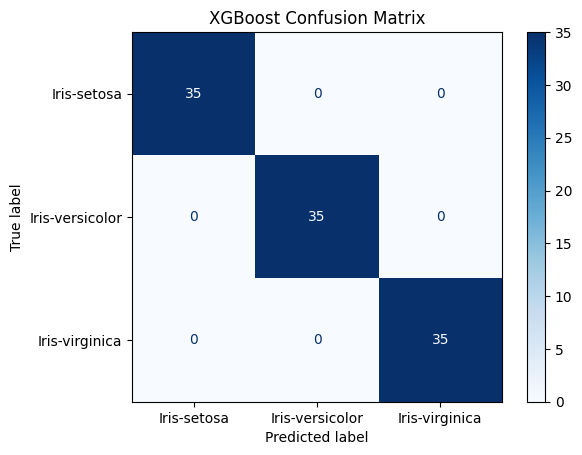

In [264]:
print("Train Set Classification Report for XGBoost Model:")
print("Accuracy:", accuracy_score(y_train, y_train_pred_xgb))
print(classification_report(y_train, y_train_pred_xgb, target_names=le.classes_))
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred_xgb, display_labels=le.classes_, cmap='Blues')
plt.title("XGBoost Confusion Matrix")
plt.show()

Test Set Classification Report for XGBoost Model:
Accuracy: 0.9333333333333333
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        15
Iris-versicolor       0.83      1.00      0.91        15
 Iris-virginica       1.00      0.80      0.89        15

       accuracy                           0.93        45
      macro avg       0.94      0.93      0.93        45
   weighted avg       0.94      0.93      0.93        45



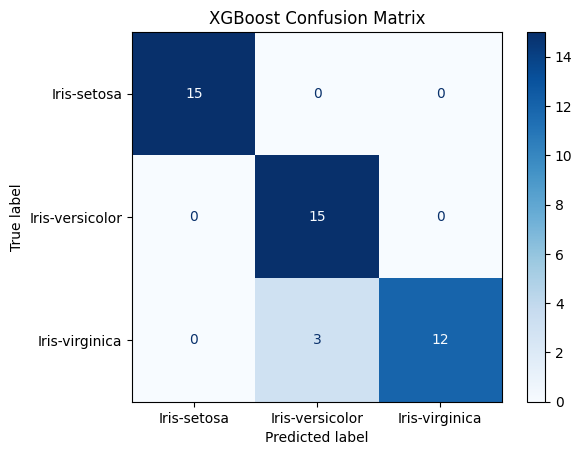

In [265]:
print("Test Set Classification Report for XGBoost Model:")
print("Accuracy:", accuracy_score(y_test, y_test_pred_xgb))
print(classification_report(y_test, y_test_pred_xgb, target_names=le.classes_))
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred_xgb, display_labels=le.classes_, cmap='Blues')
plt.title("XGBoost Confusion Matrix")
plt.show()

#### SVM

In [274]:
from sklearn import svm

svc_model = svm.SVC(kernel='rbf', random_state=42)
svc_model.fit(X_train_scaled, y_train)

y_train_pred_svc = svc_model.predict(X_train_scaled)
y_test_pred_svc = svc_model.predict(X_test_scaled)

Train Set Classification Report for SVC Model:
Accuracy: 0.9714285714285714
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        35
Iris-versicolor       0.97      0.94      0.96        35
 Iris-virginica       0.94      0.97      0.96        35

       accuracy                           0.97       105
      macro avg       0.97      0.97      0.97       105
   weighted avg       0.97      0.97      0.97       105



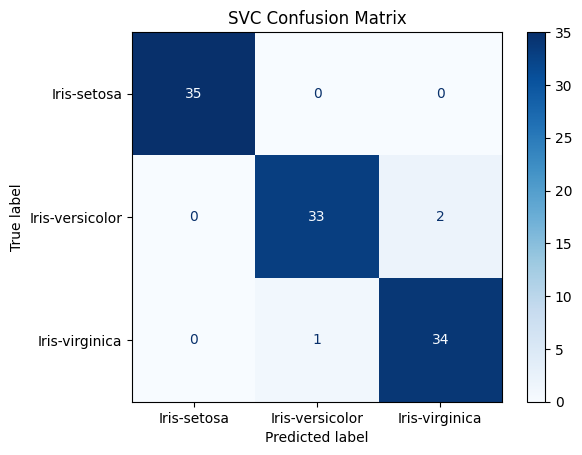

In [275]:
print("Train Set Classification Report for SVC Model:")
print("Accuracy:", accuracy_score(y_train, y_train_pred_svc))
print(classification_report(y_train, y_train_pred_svc, target_names=le.classes_))
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred_svc, display_labels=le.classes_, cmap='Blues')
plt.title("SVC Confusion Matrix")
plt.show()

Test Set Classification Report for SVC Model:
Accuracy: 0.9333333333333333
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        15
Iris-versicolor       0.88      0.93      0.90        15
 Iris-virginica       0.93      0.87      0.90        15

       accuracy                           0.93        45
      macro avg       0.93      0.93      0.93        45
   weighted avg       0.93      0.93      0.93        45



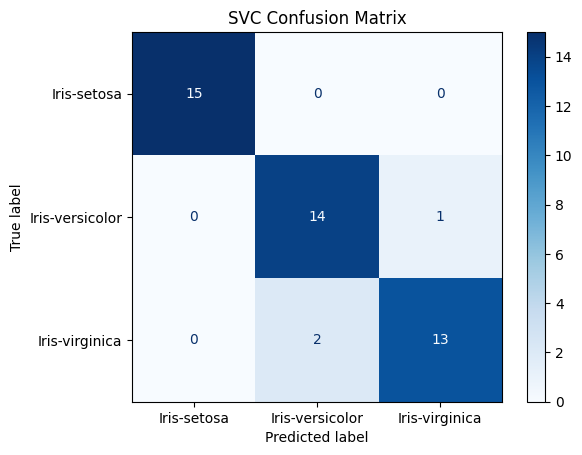

In [276]:
print("Test Set Classification Report for SVC Model:")
print("Accuracy:", accuracy_score(y_test, y_test_pred_svc))
print(classification_report(y_test, y_test_pred_svc, target_names=le.classes_))
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred_svc, display_labels=le.classes_, cmap='Blues')
plt.title("SVC Confusion Matrix")
plt.show()

#### KNN

In [283]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=1)
knn_model.fit(X_train_scaled, y_train)

y_train_pred_knn = knn_model.predict(X_train_scaled)
y_test_pred_knn = knn_model.predict(X_test_scaled)

Train Set Classification Report for KNN Model:
Accuracy: 1.0
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        35
Iris-versicolor       1.00      1.00      1.00        35
 Iris-virginica       1.00      1.00      1.00        35

       accuracy                           1.00       105
      macro avg       1.00      1.00      1.00       105
   weighted avg       1.00      1.00      1.00       105



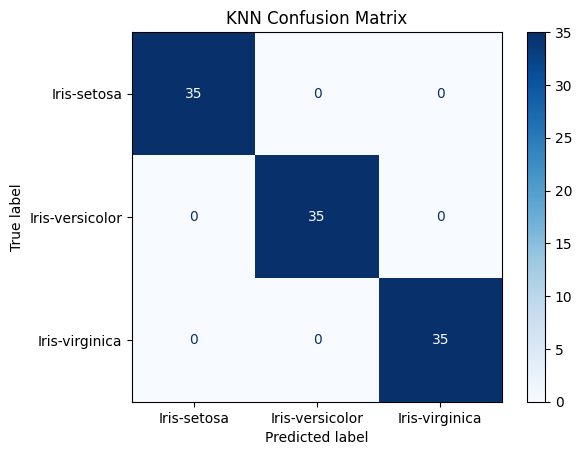

In [284]:
print("Train Set Classification Report for KNN Model:")
print("Accuracy:", accuracy_score(y_train, y_train_pred_knn))
print(classification_report(y_train, y_train_pred_knn, target_names=le.classes_))
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred_knn, display_labels=le.classes_, cmap='Blues')
plt.title("KNN Confusion Matrix")
plt.show()

Test Set Classification Report for KNN Model:
Accuracy: 0.9333333333333333
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        15
Iris-versicolor       0.83      1.00      0.91        15
 Iris-virginica       1.00      0.80      0.89        15

       accuracy                           0.93        45
      macro avg       0.94      0.93      0.93        45
   weighted avg       0.94      0.93      0.93        45



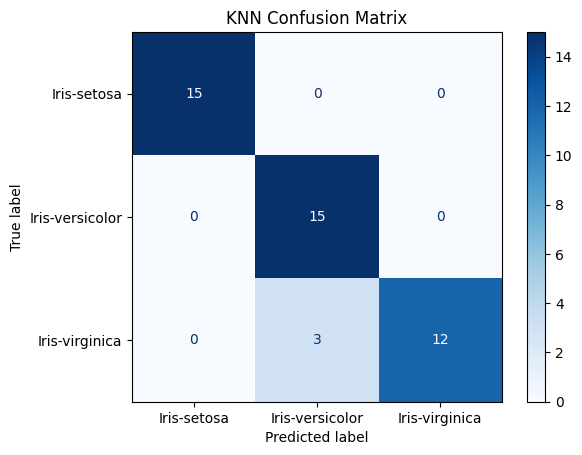

In [285]:
print("Test Set Classification Report for KNN Model:")
print("Accuracy:", accuracy_score(y_test, y_test_pred_knn))
print(classification_report(y_test, y_test_pred_knn, target_names=le.classes_))
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred_knn, display_labels=le.classes_, cmap='Blues')
plt.title("KNN Confusion Matrix")
plt.show()